In [1]:
import pandas as pd
import numpy as np
from scipy import stats

from dvi.estimators import EOTDFIEstimator
import time
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [2]:
outcome = 'sens50'
filename = f'data/{outcome}_processed_dataset.csv'
data = pd.read_csv(filename)
y = data[outcome]
X = data.drop(columns=[outcome])
df_groups = pd.read_csv('data/feature_group.csv', index_col=0).set_index('feature')
df_groups = pd.get_dummies(df_groups['group']).groupby(df_groups.index).max().reindex(X.columns)

print(f"Dataset shape: {X.shape}")
print(f"Target variable: {outcome}")
print(f"Number of groups: {len(df_groups.columns)}")
print(f"Data loaded from: {filename}")

Dataset shape: (611, 832)
Target variable: sens50
Number of groups: 14
Data loaded from: data/sens50_processed_dataset.csv


In [3]:
from sklearn.preprocessing import StandardScaler

# Prepare data
print("Data preparation...")
X_values = X.values
y_values = y.values

print(f"Feature matrix shape: {X_values.shape}")
print(f"Target vector shape: {y_values.shape}")
print(f"Target statistics: mean={y_values.mean():.3f}, std={y_values.std():.3f}")

# Check for missing values
missing_X = np.isnan(X_values).sum()
missing_y = np.isnan(y_values).sum()
print(f"Missing values - X: {missing_X}, y: {missing_y}")

# Remove any rows with missing values if needed
if missing_X > 0 or missing_y > 0:
    valid_mask = ~(np.isnan(X_values).any(axis=1) | np.isnan(y_values))
    X_values = X_values[valid_mask]
    y_values = y_values[valid_mask]
    print(f"After removing missing values: X shape = {X_values.shape}, y shape = {y_values.shape}")

# Standardize features (X)
X_scaler = StandardScaler()
X_values = X_scaler.fit_transform(X_values)

# Standardize target (y) 
y_scaler = StandardScaler()
y_values = y_scaler.fit_transform(y_values.reshape(-1, 1)).ravel()

print("After standardization:")
print(f"X mean: {X_values.mean():.3f}, std: {X_values.std():.3f}")
print(f"y mean: {y_values.mean():.3f}, std: {y_values.std():.3f}")


Data preparation...
Feature matrix shape: (611, 832)
Target vector shape: (611,)
Target statistics: mean=0.615, std=0.487
Missing values - X: 0, y: 0
After standardization:
X mean: -0.000, std: 1.000
y mean: -0.000, std: 1.000


## Fit DFI

In [4]:
# Fit DFI (EOT) estimator and compute importance scores
print("Fitting DFI (EOT) estimator with epsilon=1e-3...")
start_time = time.time()
dfi_estimator = EOTDFIEstimator(
    epsilon=0.001, n_folds=2, n_samples=100, refit_mu=False, refit_cov=False, sampling_method='resample'
    )

# Fit and compute importance scores for DFI
dfi_estimator.fit(X_values, y_values)
dfi, dfi_std = dfi_estimator.importance(X_values, y_values)
dfi_scores = dfi / np.maximum(dfi_std, 1e-12)

dfiz, dfiz_std = dfi_estimator.phi_Z, dfi_estimator.std_Z
dfiz_scores = dfiz / np.maximum(dfiz_std, 1e-12)

dfi_time = time.time() - start_time
print(f"DFI (EOT) fitting completed in {dfi_time:.2f} seconds")
print(f"DFI scores shape: {dfi_scores.shape}")

np.sum(dfi), np.sum(dfiz)

Fitting DFI (EOT) estimator with epsilon=1e-3...
DFI (EOT) fitting completed in 5594.58 seconds
DFI scores shape: (832,)


(0.7541430807089393, 0.756405073762541)

In [5]:
# Get feature names
feature_names = X.columns.tolist()
n_features = len(feature_names)

# Calculate p-values (one-sided test for positive importance)
dfi_p_values = 1 - stats.norm.cdf(dfi_scores)
dfiz_p_values = 1 - stats.norm.cdf(dfiz_scores)

# Sort features by DFI importance
dfi_ranking = np.argsort(dfi_scores)[::-1]  # Descending order
dfiz_ranking = np.argsort(dfiz_scores)[::-1]  # Descending order

# save results
results = pd.DataFrame({
    'feature': X.columns,
    'dfi': dfi,    
    'dfi_std': dfi_std,
    'dfi_zscore': dfi_scores,
    'dfi_p_value': dfi_p_values,
    'dfi_ranking': dfi_ranking,

    'dfiz': dfiz,
    'dfiz_std': dfiz_std,
    'dfiz_score': dfiz_scores,
    'dfiz_p_value': dfiz_p_values,
    'dfiz_ranking': dfiz_ranking
})
results.to_csv(f'dfi_results_{outcome}.csv', index=False)

## DFI

In [6]:
# unadjusted variance estimation

alpha = 0.05
bonferroni_alpha = alpha / n_features

print(f"Total number of features: {n_features}")
print(f"Sample size: {X_values.shape[0]}")
print(f"DFI range: [{dfi.min():.6f}, {dfi.max():.6f}]")
print(f"DFIZ range: [{dfiz.min():.6f}, {dfiz.max():.6f}]")


print("=== SUMMARY STATISTICS ===")
print(f"Dataset: {outcome}")
print(f"Number of samples: {X_values.shape[0]}")
print(f"Number of features: {X_values.shape[1]}")
print(f"\nDFI Estimator:")
print(f"  - Mean importance: {dfi.mean():.6f}")
print(f"  - Std importance: {dfi_std.std():.6f}")
print(f"  - Max importance: {dfi_std.max():.6f}")
print(f"  - Min importance: {dfi_std.min():.6f}")
print(f"\nDFIZ Estimator:")
print(f"  - Mean importance: {dfiz.mean():.6f}")
print(f"  - Std importance: {dfiz_std.std():.6f}")
print(f"  - Max importance: {dfiz_std.max():.6f}")
print(f"  - Min importance: {dfiz_std.min():.6f}")

correlation = np.corrcoef(dfi, dfiz)[0, 1]
print(f"\nCorrelation between DFI and DFIZ scores: {correlation:.4f}")



print("\n=== TOP 10 MOST IMPORTANT FEATURES (DFI) ===")
print("Rank | Feature Name                 | Importance | Std      | Z-score  | P-value  | Significant")
print("-" * 100)
for i in range(min(10, n_features)):
    idx = dfi_ranking[i]
    score = dfi[idx]
    std = dfi_std[idx]
    z_score = dfi_scores[idx]
    p_value = dfi_p_values[idx]
    feature_name = feature_names[idx]
    significant = "***" if p_value < bonferroni_alpha else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else ""))
    print(f"{i+1:4d} | {feature_name:<28} |  {score:8.6f}  | {std:8.6f} | {z_score:8.3f} | {p_value:8.6f} | {significant}")

print("\n=== TOP 10 MOST IMPORTANT FEATURES (DFIZ) ===")
print("Rank | Feature Name                 | Importance | Std      | Z-score  | P-value  | Significant")
print("-" * 100)
for i in range(min(10, n_features)):
    idx = dfiz_ranking[i]
    score = dfiz[idx]
    std = dfiz_std[idx]
    z_score = dfiz_scores[idx]
    p_value = dfiz_p_values[idx]
    feature_name = feature_names[idx]
    significant = "***" if p_value < bonferroni_alpha else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else ""))
    print(f"{i+1:4d} | {feature_name:<28} |  {score:8.6f}  | {std:8.6f} | {z_score:8.3f} | {p_value:8.6f} | {significant}")

# Count significant features
dfi_significant_bonferroni = np.sum(dfi_p_values < bonferroni_alpha)
dfiz_significant_bonferroni = np.sum(dfiz_p_values < bonferroni_alpha)
dfi_significant_raw = np.sum(dfi_p_values < 0.05)
dfiz_significant_raw = np.sum(dfiz_p_values < 0.05)

print(f"\n=== SIGNIFICANCE SUMMARY ===")
print(f"DFI - Significant features (Bonferroni): {dfi_significant_bonferroni}/{n_features}")
print(f"DFI - Significant features (uncorrected): {dfi_significant_raw}/{n_features}")
print(f"DFIZ - Significant features (Bonferroni): {dfiz_significant_bonferroni}/{n_features}")
print(f"DFIZ - Significant features (uncorrected): {dfiz_significant_raw}/{n_features}")

print("\nSignificance levels: *** p < Bonferroni, ** p < 0.01, * p < 0.05")


Total number of features: 832
Sample size: 611
DFI range: [0.000000, 0.015648]
DFIZ range: [0.000000, 0.034786]
=== SUMMARY STATISTICS ===
Dataset: sens50
Number of samples: 611
Number of features: 832

DFI Estimator:
  - Mean importance: 0.000906
  - Std importance: 0.000227
  - Max importance: 0.002082
  - Min importance: 0.000000

DFIZ Estimator:
  - Mean importance: 0.000909
  - Std importance: 0.000486
  - Max importance: 0.004863
  - Min importance: 0.000000

Correlation between DFI and DFIZ scores: 0.9797

=== TOP 10 MOST IMPORTANT FEATURES (DFI) ===
Rank | Feature Name                 | Importance | Std      | Z-score  | P-value  | Significant
----------------------------------------------------------------------------------------------------
   1 | hxb2.389.G.1mer              |  0.000817  | 0.000074 |   11.011 | 0.000000 | ***
   2 | hxb2.136.sequon_actual.1mer  |  0.000758  | 0.000069 |   10.978 | 0.000000 | ***
   3 | hxb2.354.P.1mer              |  0.000860  | 0.000080 |  

In [7]:
# Significance by enlarging CIs (DFI only, one-sided test)
# Use adjusted std matching the group DFI approach: add 0.1/sqrt(n)/z_0.95

n = len(X_values)
dfi_adj_std = np.maximum(dfi_std, 1e-12) + 0.01 / np.sqrt(n) / stats.norm.ppf(0.95)
dfiz_adj_std = np.maximum(dfiz_std, 1e-12) + 0.01 / np.sqrt(n) / stats.norm.ppf(0.95)

z_crit = stats.norm.ppf(1 - alpha)
bonf_z = stats.norm.ppf(1 - alpha / n_features)

# Significance: lower bound of one-sided CI > 0
sig_raw = np.sum(dfi - z_crit * dfi_adj_std > 0)
sig_bonf = np.sum(dfi - bonf_z * dfi_adj_std > 0)

print("=== SIGNIFICANCE BY ENLARGING CIs (DFI, adjusted std, one-sided) ===\n")
print(f"95% one-sided CI (z={z_crit:.3f}): {sig_raw}/{n_features} significant features")
print(f"Bonferroni one-sided CI (z={bonf_z:.3f}): {sig_bonf}/{n_features} significant features")

sig_raw_z = np.sum(dfiz - z_crit * dfiz_adj_std > 0)
sig_bonf_z = np.sum(dfiz - bonf_z * dfiz_adj_std > 0)
print(f"\n=== SIGNIFICANCE BY ENLARGING CIs (DFIZ, adjusted std, one-sided) ===\n")
print(f"95% one-sided CI (z={z_crit:.3f}): {sig_raw_z}/{n_features} significant features")
print(f"Bonferroni one-sided CI (z={bonf_z:.3f}): {sig_bonf_z}/{n_features} significant features")

=== SIGNIFICANCE BY ENLARGING CIs (DFI, adjusted std, one-sided) ===

95% one-sided CI (z=1.645): 369/832 significant features
Bonferroni one-sided CI (z=3.846): 30/832 significant features

=== SIGNIFICANCE BY ENLARGING CIs (DFIZ, adjusted std, one-sided) ===

95% one-sided CI (z=1.645): 154/832 significant features
Bonferroni one-sided CI (z=3.846): 19/832 significant features


## Group DFI

In [8]:
res = []
for group in df_groups.columns:
    uncentered_eifs = dfi_estimator.ueifs.copy()
    uncentered_eifs = np.sum(uncentered_eifs[:, df_groups[group].values == True], axis=1)
    if np.mean(uncentered_eifs) < 0:
        uncentered_eifs[:] = 0
    fi = np.mean(uncentered_eifs)
    sigma = np.std(uncentered_eifs, ddof=1)
    std = np.maximum(
        sigma / np.sqrt(len(uncentered_eifs)), 1e-12) + .01 * 14 / np.sqrt(len(X_values)) / stats.norm.ppf(0.95)  # Adjusted standard error

    res.append({
        'group': group,
        'importance': fi,
        'std': std,
        'zscore': fi / std if std > 0 else np.nan,
        'p_value': 1 - stats.norm.cdf(fi / std) if std > 0 else np.nan
    })
res_df = pd.DataFrame(res)

In [9]:
# Sort groups by importance for better visualization
res_df_sorted = res_df.sort_values('importance', ascending=True)

# Apply Bonferroni correction to group-level results
bonferroni_alpha_groups = 0.05 / len(res_df)
res_df_sorted['bonferroni_significant'] = res_df_sorted['p_value'] < bonferroni_alpha_groups

print(f"=== BONFERRONI CORRECTION FOR GROUPS ===")
print(f"Number of groups: {len(res_df)}")
print(f"Bonferroni corrected alpha: {bonferroni_alpha_groups:.6f}")
print(f"Groups significant after Bonferroni correction: {res_df_sorted['bonferroni_significant'].sum()}")

# Print summary table with Bonferroni correction
print(f"\n=== FEATURE GROUP ANALYSIS (WITH BONFERRONI CORRECTION) ===")
print(f"{'Group':<30} {'Importance':<12} {'Std':<10} {'Z-score':<10} {'P-value':<10} {'Sig':<5} {'Bonf'}")
print("-" * 90)
for _, row in res_df_sorted.iterrows():
    sig = "***" if row['p_value'] < 0.001 else ("**" if row['p_value'] < 0.01 else ("*" if row['p_value'] < 0.05 else ""))
    bonf_sig = "***" if row['bonferroni_significant'] else ""
    print(f"{row['group']:<30} {row['importance']:<12.6f} {row['std']:<10.6f} {row['zscore']:<10.3f} {row['p_value']:<10.6f} {sig:<5} {bonf_sig}")



=== BONFERRONI CORRECTION FOR GROUPS ===
Number of groups: 14
Bonferroni corrected alpha: 0.003571
Groups significant after Bonferroni correction: 11

=== FEATURE GROUP ANALYSIS (WITH BONFERRONI CORRECTION) ===
Group                          Importance   Std        Z-score    P-value    Sig   Bonf
------------------------------------------------------------------------------------------
geog                           0.003154     0.003675   0.858      0.195314         
steric_bulk                    0.006393     0.004043   1.581      0.056904         
subtype                        0.008828     0.004151   2.127      0.016725   *     
cysteines                      0.011998     0.004443   2.701      0.003459   **    ***
gp41                           0.027814     0.005756   4.832      0.000001   ***   ***
geometry                       0.035765     0.006393   5.594      0.000000   ***   ***
sequons                        0.037704     0.006327   5.959      0.000000   ***   ***
glyco     

In [10]:
# Create a DataFrame mapping group numbers to their definitions
group_mapping = pd.DataFrame({
    'group_num': range(1, 15),
    'group':['vrc01', 'cd4bs', 'esa', 'glyco', 'covar', 'pngs', 'gp41', 'pngs_novrc01',  
       'subtype', 'sequons', 'geometry', 'cysteines', 'steric_bulk', 'geog'],
    'description': [
        'VRC01 binding footprint',
        'CD4 binding sites', 
        'Sites with sufficient exposed surface area',
        'Sites identified as important for glycosylation',
        'Sites with residues that covary with\nthe VRC01 binding footprint',
        'Sites associated with VRC01-specific\npotential N-linked glycosylation (PNGS) effects',
        'gp41 sites important for VRC01 binding',
        'Sites for indicating N-linked glycosylation',
        'Majority virus subtypes',
        'Region-specific counts of PNGS',
        'Viral geometry',
        'Cysteine counts',
        'Steric bulk at critical locations',
        'Geographic confounders'
    ]
})


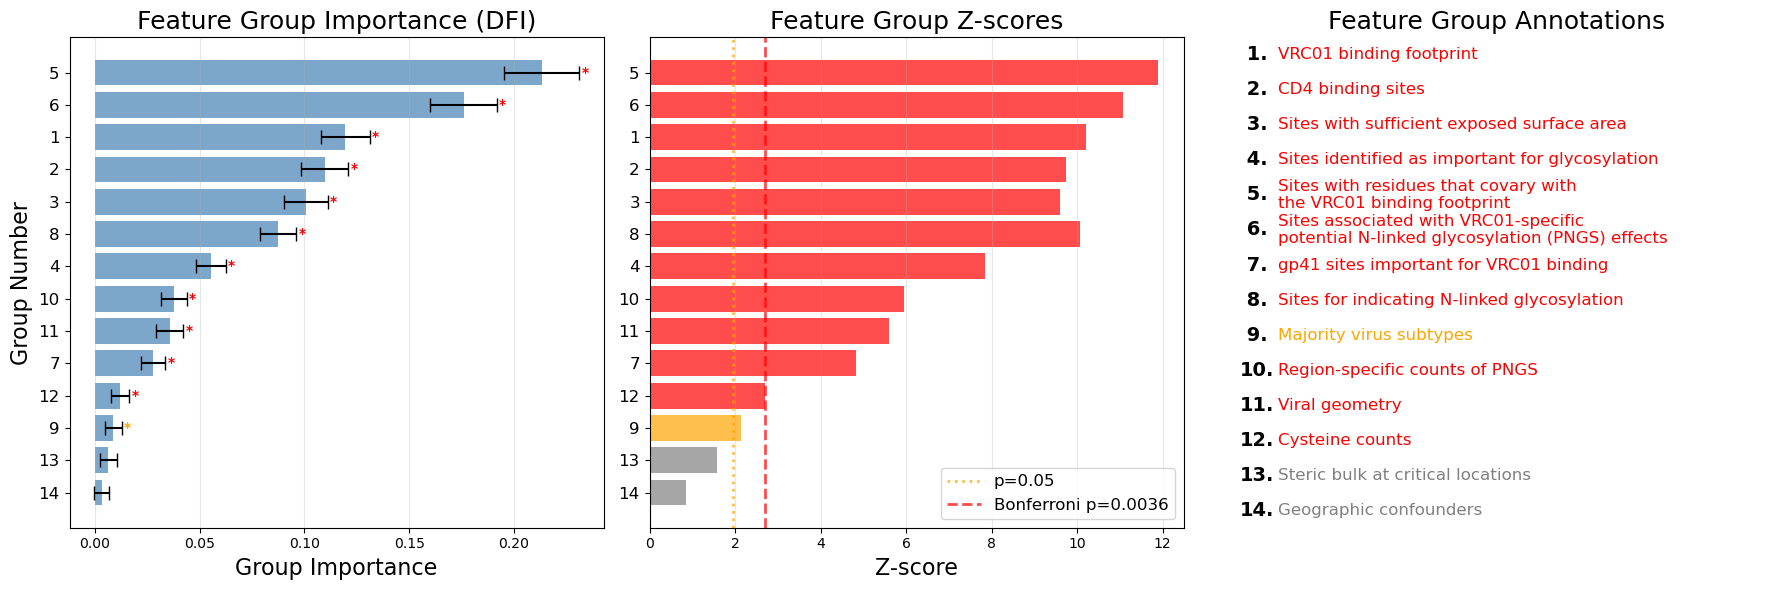

In [11]:
# Enhanced 3-column plot with group_mapping annotations

# Sort groups by importance for better visualization
res_df_sorted = res_df.sort_values('importance', ascending=True)

# Apply Bonferroni correction to group-level results
bonferroni_alpha_groups = 0.05 / len(res_df)
res_df_sorted['bonferroni_significant'] = res_df_sorted['p_value'] < bonferroni_alpha_groups

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [3, 3, 3]})

# Create group numbers for ytick labels
group_numbers = list(group_mapping.set_index('group').reindex(res_df_sorted['group'].values)['group_num'])

# Left plot: Group importance with error bars
ax1 = axes[0]
bars = ax1.barh(range(len(res_df_sorted)), res_df_sorted['importance'], 
                xerr=res_df_sorted['std'], error_kw=dict(lolims=0, capsize=5), alpha=0.7, color='steelblue')
ax1.set_yticks(range(len(res_df_sorted)))
ax1.set_yticklabels(group_numbers, fontsize=12)
ax1.set_xlabel('Group Importance', fontsize=16)
ax1.set_title('Feature Group Importance (DFI)', fontsize=18)
ax1.set_ylabel('Group Number', fontsize=16)
ax1.grid(axis='x', alpha=0.3)

# Add Bonferroni significance markers
for i, (_, row) in enumerate(res_df_sorted.iterrows()):
    if row['bonferroni_significant']:
        marker = '*'
        color = 'red'
    elif row['p_value'] < 0.05:
        marker = '*'
        color = 'orange'
    else:
        marker = ''
        color = 'orange'
    
    if marker:
        ax1.text(row['importance'] + row['std'] + 0.001, i, marker, 
                va='center', fontweight='bold', color=color)

# Middle plot: Z-scores
ax2 = axes[1]
colors = ['red' if bonf else ('orange' if p < 0.05 else 'gray') 
          for p, bonf in zip(res_df_sorted['p_value'], res_df_sorted['bonferroni_significant'])]
bars2 = ax2.barh(range(len(res_df_sorted)), res_df_sorted['zscore'], 
                 alpha=0.7, color=colors)
ax2.set_yticks(range(len(res_df_sorted)))
ax2.set_yticklabels(group_numbers, fontsize=12)
ax2.set_xlabel('Z-score', fontsize=16)
ax2.set_title('Feature Group Z-scores', fontsize=18)
ax2.set_ylabel('', fontsize=16)
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(x=1.96, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='p=0.05')
bonf_threshold = stats.norm.ppf(1 - bonferroni_alpha_groups)
ax2.axvline(x=bonf_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7, 
           label=f'Bonferroni p={bonferroni_alpha_groups:.4f}')
ax2.legend(fontsize=12)  # Adjust legend font size

# Right plot: Group annotations using group_mapping
ax3 = axes[2]
ax3.set_xlim(0, 1)
ax3.set_ylim(-0.5, len(res_df_sorted) - 0.5)



for i, (_, row) in enumerate(res_df_sorted.iterrows()):
    group_name = row['group']
    
    # Get group info from group_mapping if it exists
    try:
        group_info = group_mapping[group_mapping['group'] == group_name]
        if len(group_info) > 0:
            display_name = group_info.iloc[0].get('description', group_name)
            description = ''
        else:
            display_name = group_name
            description = ''
    except:
        # Fallback if group_mapping doesn't exist or has different structure
        display_name = group_name
        description = ''
    
    # Color based on significance
    if row['bonferroni_significant']:
        text_color = 'red'
        fontweight = 'normal'
    elif row['p_value'] < 0.05:
        text_color = 'orange'
        fontweight = 'normal'
    else:
        text_color = 'gray'
        fontweight = 'normal'
    
    # Add group number and name
    ax3.text(0.02, 14-group_numbers[i], f"{group_numbers[i]:2d}.", 
             va='center', ha='left', fontsize=14, fontweight='bold', color='black')
    ax3.text(0.09, 14-group_numbers[i], display_name, 
             va='center', ha='left', fontsize=12, fontweight=fontweight, color=text_color)
    
    # Add description if available
    if description:
        desc_text = description if len(description) <= 45 else description[:42] + "..."
        ax3.text(0.08, 14-group_numbers[i] - 0.15, desc_text, 
                 va='center', ha='left', fontsize=9, style='italic', color='gray')

ax3.set_yticks([])
ax3.set_xticks([])
ax3.set_title('Feature Group Annotations', fontsize=18)
for spine in ax3.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('figures/read_data.pdf', dpi=300, bbox_inches='tight')


## Sensitivity analysis: group importance across $\varepsilon \in \{10^{-3}, 10^{-2}, 10^{-1}\}$

In [12]:
# Sensitivity analysis: fit DFI for different epsilon values and compute group importance
epsilons = [1e-3, 1e-2, 1e-1]
group_results = {}

for eps in epsilons:
    print(f"\n=== Fitting EOTDFIEstimator with epsilon={eps} ===")
    start_time = time.time()
    
    estimator = EOTDFIEstimator(
        epsilon=eps, n_folds=2, n_samples=100, refit_mu=False, refit_cov=False, sampling_method='resample'
    )
    estimator.fit(X_values, y_values)
    estimator.importance(X_values, y_values)
    
    elapsed = time.time() - start_time
    print(f"  Completed in {elapsed:.2f} seconds")
    
    # Compute group-level importance (same logic as above)
    res_eps = []
    for group in df_groups.columns:
        uncentered_eifs = estimator.ueifs.copy()
        uncentered_eifs = np.sum(uncentered_eifs[:, df_groups[group].values == True], axis=1)
        if np.mean(uncentered_eifs) < 0:
            uncentered_eifs[:] = 0
        fi = np.mean(uncentered_eifs)
        sigma = np.std(uncentered_eifs, ddof=1)
        std = np.maximum(
            sigma / np.sqrt(len(uncentered_eifs)), 1e-12
        ) + 0.01 * 14 / np.sqrt(len(X_values)) / stats.norm.ppf(0.95)
        
        res_eps.append({
            'group': group,
            'importance': fi,
            'std': std,
            'zscore': fi / std if std > 0 else np.nan,
            'p_value': 1 - stats.norm.cdf(fi / std) if std > 0 else np.nan
        })
    
    group_results[eps] = pd.DataFrame(res_eps)
    print(f"  Groups with p < 0.05: {(group_results[eps]['p_value'] < 0.05).sum()}/{len(df_groups.columns)}")

print("\nSensitivity analysis complete.")


=== Fitting EOTDFIEstimator with epsilon=0.001 ===
  Completed in 1846.61 seconds
  Groups with p < 0.05: 12/14

=== Fitting EOTDFIEstimator with epsilon=0.01 ===
  Completed in 1959.53 seconds
  Groups with p < 0.05: 12/14

=== Fitting EOTDFIEstimator with epsilon=0.1 ===
  Completed in 2365.21 seconds
  Groups with p < 0.05: 13/14

Sensitivity analysis complete.


In [13]:
from pathlib import Path

# Create output folder
save_dir = Path("results/intermediate")
save_dir.mkdir(parents=True, exist_ok=True)

# Save each epsilon result
for eps, df_eps in group_results.items():
    eps_label = f"{eps:.0e}"  # e.g., 1e-03
    df_eps.to_csv(save_dir / f"group_importance_{outcome}_eps_{eps_label}.csv", index=False)

# Save all epsilon results in one table
group_results_long = pd.concat(
    [df.assign(epsilon=eps) for eps, df in group_results.items()],
    ignore_index=True
)
group_results_long.to_csv(save_dir / f"group_importance_{outcome}_all_eps.csv", index=False)

# Save a compact snapshot of current loop variables
np.savez(
    save_dir / f"snapshot_{outcome}.npz",
    fi=fi,
    sigma=sigma,
    std=std,
    group=group,
    filename=filename
)

print(f"Intermediate results saved to: {save_dir.resolve()}")

Intermediate results saved to: /Users/dujinhong/Documents/study/Kathryn Roeder/Project/disentangled feature importance/dfi/results/intermediate


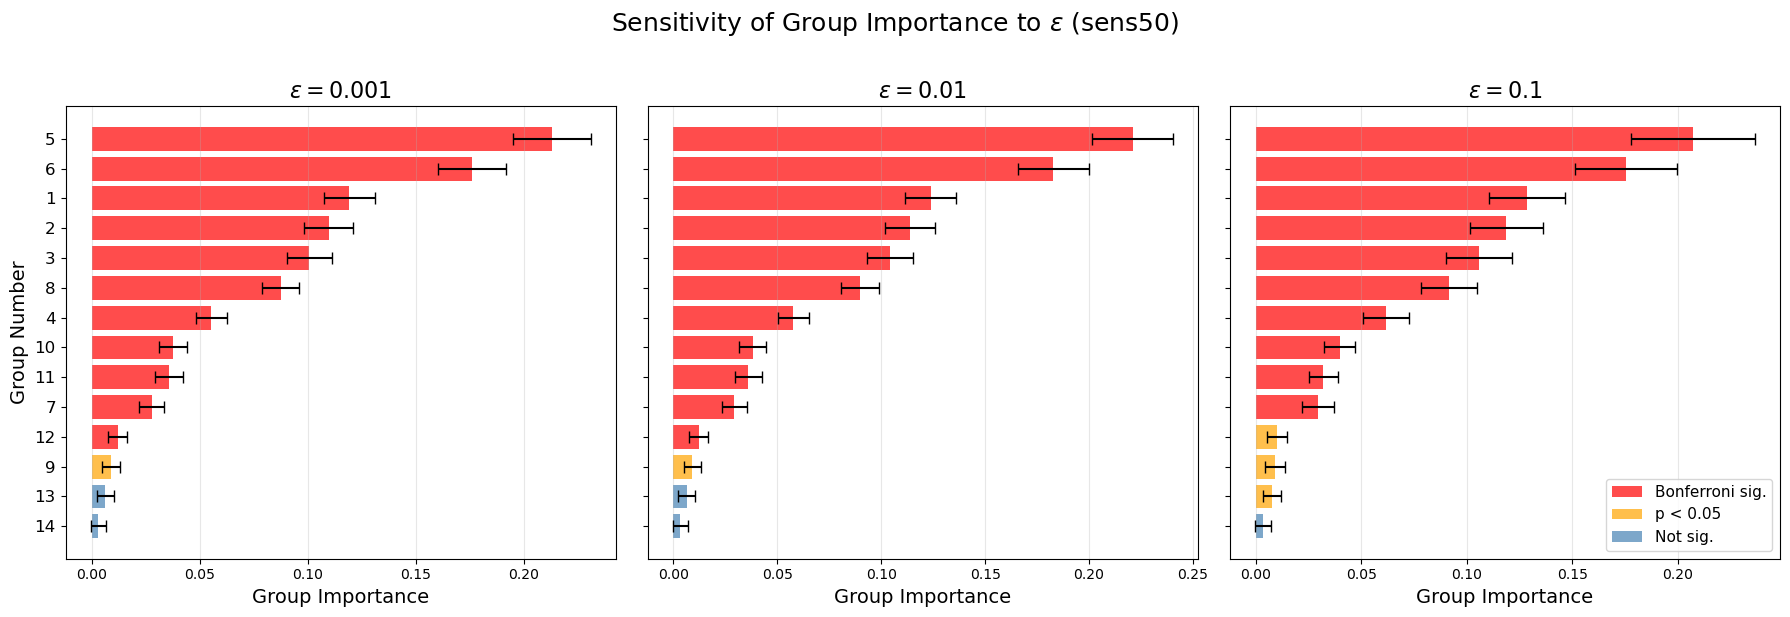

In [14]:
# Plot sensitivity analysis: group importance across epsilon values
n_groups = len(df_groups.columns)
bonferroni_alpha_groups = 0.05 / n_groups

fig, axes = plt.subplots(1, len(epsilons), figsize=(6 * len(epsilons), 6), sharey=True)

for ax_idx, eps in enumerate(epsilons):
    
    ax = axes[ax_idx]
    df_eps = group_results[eps].sort_values('importance', ascending=True)
    group_nums = list(group_mapping.set_index('group').reindex(df_eps['group'].values)['group_num'])
    
    colors = ['red' if p < bonferroni_alpha_groups else ('orange' if p < 0.05 else 'steelblue')
              for p in df_eps['p_value']]
    
    ax.barh(range(n_groups), df_eps['importance'],
            xerr=df_eps['std'], error_kw=dict(lolims=0, capsize=4),
            alpha=0.7, color=colors)
    ax.set_yticks(range(n_groups))
    ax.set_yticklabels(group_nums, fontsize=12)
    ax.set_xlabel('Group Importance', fontsize=14)
    ax.set_title(f'$\\varepsilon = {eps}$', fontsize=16)
    ax.grid(axis='x', alpha=0.3)

axes[0].set_ylabel('Group Number', fontsize=14)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='Bonferroni sig.'),
    Patch(facecolor='orange', alpha=0.7, label='p < 0.05'),
    Patch(facecolor='steelblue', alpha=0.7, label='Not sig.')
]
axes[-1].legend(handles=legend_elements, fontsize=11, loc='lower right')

plt.suptitle(f'Sensitivity of Group Importance to $\\varepsilon$ ({outcome})', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(f'figures/sensitivity_epsilon_{outcome}.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Summary table: group importance across epsilon values
bonferroni_alpha_groups = 0.05 / len(df_groups.columns)

print(f"{'Group':<30}", end="")
for eps in epsilons:
    print(f"  eps={eps:<8}  ", end="")
print()
print("-" * (30 + 14 * len(epsilons)))

# Use consistent group ordering
ref_order = group_results[epsilons[0]].sort_values('importance', ascending=False)['group'].values

for group in ref_order:
    gnum = group_mapping[group_mapping['group'] == group]['group_num'].values[0]
    print(f"{gnum:2d}. {group:<26}", end="")
    for eps in epsilons:
        row = group_results[eps][group_results[eps]['group'] == group].iloc[0]
        sig = "***" if row['p_value'] < bonferroni_alpha_groups else ("* " if row['p_value'] < 0.05 else "  ")
        print(f"  {row['importance']:7.4f} {sig} ", end="")
    print()

print(f"\nSignificance: *** Bonferroni (p < {bonferroni_alpha_groups:.4f}), * p < 0.05")

Group                           eps=0.001       eps=0.01        eps=0.1       
------------------------------------------------------------------------
 5. covar                        0.2121 ***    0.2201 ***    0.2097 *** 
 6. pngs                         0.1750 ***    0.1819 ***    0.1770 *** 
 1. vrc01                        0.1186 ***    0.1232 ***    0.1297 *** 
 2. cd4bs                        0.1091 ***    0.1134 ***    0.1200 *** 
 3. esa                          0.1002 ***    0.1039 ***    0.1069 *** 
 8. pngs_novrc01                 0.0873 ***    0.0896 ***    0.0925 *** 
 4. glyco                        0.0551 ***    0.0574 ***    0.0621 *** 
10. sequons                      0.0378 ***    0.0383 ***    0.0399 *** 
11. geometry                     0.0357 ***    0.0360 ***    0.0320 *** 
 7. gp41                         0.0277 ***    0.0291 ***    0.0298 *** 
12. cysteines                    0.0119 *     0.0121 *     0.0100    
 9. subtype                      0.0088       0.